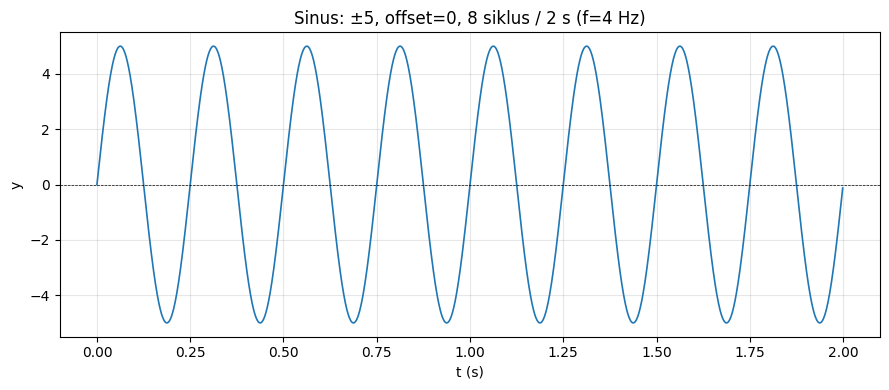

In [7]:
import numpy as np
import matplotlib.pyplot as plt

A = 5.0  # amplitudo puncak: y berkisar di [-A, +A]
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
y = A * np.sin(2 * np.pi * f * t)  # tanpa offset (DC = 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus: ±{A:g}, offset=0, {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A * 1.1, A * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

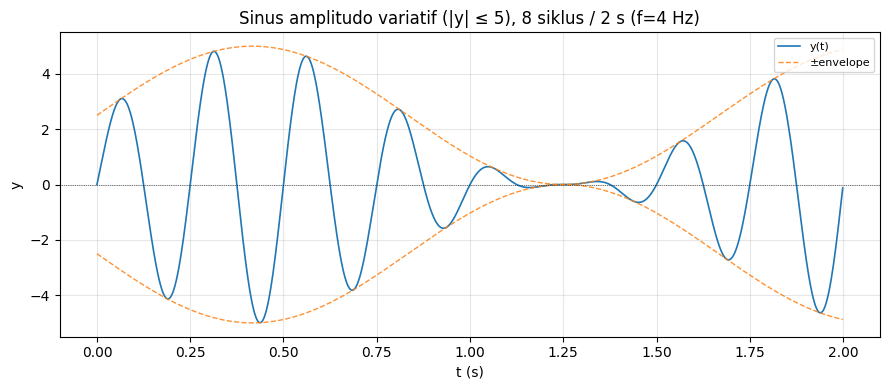

In [8]:
"""
Sinus amplitudo variatif — modulasi amplitudo (AM).

Idea:
- Carrier: sin(2*pi*f*t), nilai di [-1, 1].
- Envelope: (A_max/2) * (1 + sin(2*pi*f_env*t)), selalu di [0, A_max].
- Sinyal: y(t) = envelope(t) * carrier(t).

Batas |y| <= A_max:
Karena |carrier| <= 1, maka |y(t)| <= envelope(t) <= A_max.
Saat sin(...)=-1 envelope=0; saat sin(...)=+1 envelope=A_max.

Parameter:
- f_env: laju variasi amplop (Hz), biasanya lebih kecil dari f carrier.
- f, n_cycles, T, fs: sama konsepnya dengan sel 0 (jumlah siklus carrier dalam T).
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
# Envelope amplitudo variatif dalam [0, A_max] → |envelope * sin| ≤ A_max
f_env = 0.6  # frekuensi modulasi amplitudo (Hz), lebih rendah dari carrier
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
carrier = np.sin(2 * np.pi * f * t)
y = envelope * carrier  # tanpa offset DC pada carrier; envelope bermean >0 tapi y tetap |y|≤A_max

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2, label="y(t)")
ax.plot(t, envelope, color="C1", lw=1.0, ls="--", alpha=0.85, label="±envelope")
ax.plot(t, -envelope, color="C1", lw=1.0, ls="--", alpha=0.85)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus amplitudo variatif (|y| ≤ {A_max:g}), {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A_max * 1.1, A_max * 1.1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

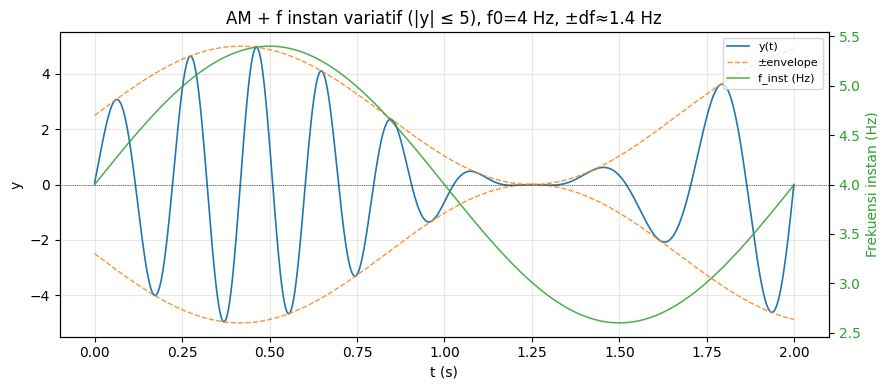

In [9]:
"""
AM + frekuensi instan variatif (FM lewat integrasi fasa).

- Amplitudo: envelope(t) di [0, A_max] seperti sel 1; y(t) = envelope(t) * carrier(t).
- Frekuensi instan: f_inst(t) = f0 + df * sin(2*pi*f_fm*t), dipotong ke f_min agar > 0.
- Fasa: phi = kumulatif sum(2*pi*f_inst*dt); carrier = sin(phi) (bukan sin(2*pi*f0*t)).

f0 = n_cycles/T sebagai pusat; df lebar ayunan Hz; f_fm laju modulasi frekuensi.
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus rata-rata ~f0*T: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T  # pusat frekuensi instan (Hz)

dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6  # modulasi amplitudo (Hz)
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))

f_fm = 0.5  # modulasi frekuensi (Hz)
df = 0.35 * f0  # setengah-lebar ayunan frekuensi instan (Hz)
f_min = 0.15  # lantai Hz agar f_inst selalu positif
f_inst = f0 + df * np.sin(2 * np.pi * f_fm * t)
f_inst = np.clip(f_inst, f_min, None)

phi = np.cumsum(2 * np.pi * f_inst * dt)
carrier = np.sin(phi)
y = envelope * carrier

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2, label="y(t)")
ax.plot(t, envelope, color="C1", lw=1.0, ls="--", alpha=0.85, label="±envelope")
ax.plot(t, -envelope, color="C1", lw=1.0, ls="--", alpha=0.85)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(
    f"AM + f instan variatif (|y| ≤ {A_max:g}), f0={f0:g} Hz, ±df≈{df:g} Hz"
)
ax.set_ylim(-A_max * 1.1, A_max * 1.1)

ax2 = ax.twinx()
ax2.plot(t, f_inst, color="C2", lw=1.1, alpha=0.85, label="f_inst (Hz)")
ax2.set_ylabel("Frekuensi instan (Hz)", color="C2")
ax2.tick_params(axis="y", labelcolor="C2")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

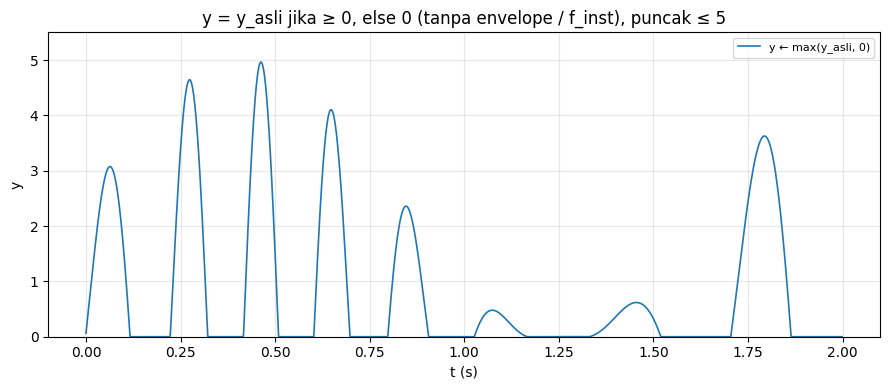

In [10]:
"""
Salinan logika sel sebelumnya (AM + f instan variatif).

Setelah y dihitung: jika y >= 0 pakai nilai asli, jika tidak y = 0
(setara np.maximum(y, 0) / half-wave ke nol). Tanpa envelope dan f_inst.
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus rata-rata ~f0*T: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T  # pusat frekuensi instan (Hz)

dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6  # modulasi amplitudo (Hz)
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))

f_fm = 0.5  # modulasi frekuensi (Hz)
df = 0.35 * f0  # setengah-lebar ayunan frekuensi instan (Hz)
f_min = 0.15  # lantai Hz agar f_inst selalu positif
f_inst = f0 + df * np.sin(2 * np.pi * f_fm * t)
f_inst = np.clip(f_inst, f_min, None)

phi = np.cumsum(2 * np.pi * f_inst * dt)
carrier = np.sin(phi)
y = envelope * carrier

y_plot = np.where(y >= 0, y, 0.0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y_plot, color="C0", lw=1.2, label="y ← max(y_asli, 0)")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"y = y_asli jika ≥ 0, else 0 (tanpa envelope / f_inst), puncak ≤ {A_max:g}")
ax.set_ylim(0, A_max * 1.1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
Deteksi region (Schmitt trigger / hysteresis) pada sinyal y = max(y_asli, 0).

- Threshold referensi: 2.0
- Hysteresis: ±0.05 → masuk region saat y >= TH_HIGH (2.05), keluar saat y <= TH_LOW (1.95)
  (mirip komparator Schmitt: noise di sekitar 2 tidak memecah region berlebihan)

Per region: kumpulkan array t dan y untuk sampel dari crossing naik sampai crossing turun.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- bangkit sinyal (sama seperti sel rectified / AM+FM) ---
A_max = 5.0
T = 2.0
fs = 1000
n_cycles = 8
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T
dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
f_fm = 0.5
df = 0.35 * f0
f_min = 0.15
f_inst = np.clip(f0 + df * np.sin(2 * np.pi * f_fm * t), f_min, None)
phi = np.cumsum(2 * np.pi * f_inst * dt)
y = envelope * np.sin(phi)
y_sig = np.where(y >= 0, y, 0.0)

# --- Schmitt: pusat 2, hysteresis ±0.05 ---
TH = 2.0
HY = 0.05
TH_HIGH = TH + HY  # 2.05
TH_LOW = TH - HY  # 1.95

n = len(y_sig)
active = False
start_idx = 0
regions = []

if n > 0 and y_sig[0] >= TH_HIGH:
    active = True
    start_idx = 0

for i in range(n):
    yv = y_sig[i]
    if not active:
        if yv >= TH_HIGH:
            active = True
            start_idx = i
    else:
        if yv <= TH_LOW:
            regions.append(
                {
                    "i0": start_idx,
                    "i1": i,
                    "t": t[start_idx : i + 1].copy(),
                    "y": y_sig[start_idx : i + 1].copy(),
                }
            )
            active = False

if active:
    regions.append(
        {
            "i0": start_idx,
            "i1": n - 1,
            "t": t[start_idx:n].copy(),
            "y": y_sig[start_idx:n].copy(),
        }
    )

print(f"TH={TH}, HY=±{HY} → naik ≥ {TH_HIGH}, turun ≤ {TH_LOW}")
print(f"Jumlah region terdeteksi: {len(regions)}\n")
for k, r in enumerate(regions, start=1):
    print(
        f"Region {k}: n_sampel={len(r['y'])}, "
        f"t ∈ [{r['t'][0]:.5f}, {r['t'][-1]:.5f}] s, "
        f"y_max={r['y'].max():.4f}, y_min={r['y'].min():.4f}"
    )

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y_sig, color="C0", lw=1.2, label="y (rectified)")
for r in regions:
    ax.axvspan(r["t"][0], r["t"][-1], alpha=0.22, color="C1", label="_nolegend_")
ax.axhline(TH, color="k", lw=0.7, ls=":", label=f"TH = {TH:g}")
ax.axhline(TH_HIGH, color="C3", lw=1.0, ls="--", label=f"TH_HIGH = {TH_HIGH:g} (masuk)")
ax.axhline(TH_LOW, color="C2", lw=1.0, ls="--", label=f"TH_LOW = {TH_LOW:g} (keluar)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title("Region (Schmitt): y ≥ TH_HIGH → … → y ≤ TH_LOW")
ax.set_ylim(0, A_max * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()